<a href="https://colab.research.google.com/github/ealeongomez/RFF-HBO-TSF/blob/main/test/Custom_Layer_RFF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Preliminares**

In [ ]:
!pip install torchinfo optuna botorch gpytorch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.9/779.9 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.7/277.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.3/176.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 3.2 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/ealeongomez/RFF-HBO-TSF.git

Cloning into 'RFF-HBO-TSF'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 64 (delta 20), reused 38 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 24.54 MiB | 5.57 MiB/s, done.
Resolving deltas: 100% (20/20), done.
Updating files: 100% (13/13), done.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math, pickle
from tqdm import tqdm
from scipy.interpolate import griddata

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
#from torchinfo import summary
from torchsummary import summary
from torch.utils.data import TensorDataset, DataLoader

import optuna
import optuna.visualization as vis
#from optuna_integration.botorch import BoTorchSampler
from optuna.samplers import TPESampler
from optuna.samplers import GPSampler
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_slice, plot_parallel_coordinate

from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.gaussian_process import GaussianProcessRegressor

import warnings
warnings.filterwarnings("ignore")

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# **Load dataset**

In [ ]:
def detect_environment():
    # Kaggle
    if "KAGGLE_KERNEL_RUN_TYPE" in os.environ:
        return "Kaggle"

    # Google Colab
    try:
        import google.colab
        pkl_filename = "/content/RFF-HBO-TSF/Data/data_dict.pkl"
        return "Google Colab", pkl_filename
    except ImportError:
        pass
    # Local u otro entorno
    return "Local/Other"

value_, pkl_filename = detect_environment()

print("Entorno detectado:", value_)


Entorno detectado: Google Colab


In [ ]:
with open(pkl_filename, "rb") as f:
    data_dict_loaded = pickle.load(f)

In [ ]:
def make_loader(X_arr, y_arr, batch_size, shuffle=False):
    ds = TensorDataset(torch.tensor(X_arr, dtype=torch.float32), torch.tensor(y_arr, dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size, shuffle=False)

In [ ]:
data_dict_loaded.keys()

dict_keys(['Etiopia-April', 'Etiopia-May', 'Argone', 'Beijing', 'Chengdu', 'Netherland-0', 'Netherland-1', 'Netherland-2', 'Lorenz systems 0.5', 'Lorenz systems 3', 'Lorenz systems 5'])

In [ ]:
names_TSF = ['Argone']

In [ ]:
data_dict_loaded[names_TSF[0]].keys()

dict_keys(['X', 'Y', 'time_series', 'Max'])

In [ ]:
data_dict_loaded[names_TSF[0]]['Max']

np.float64(32.44)

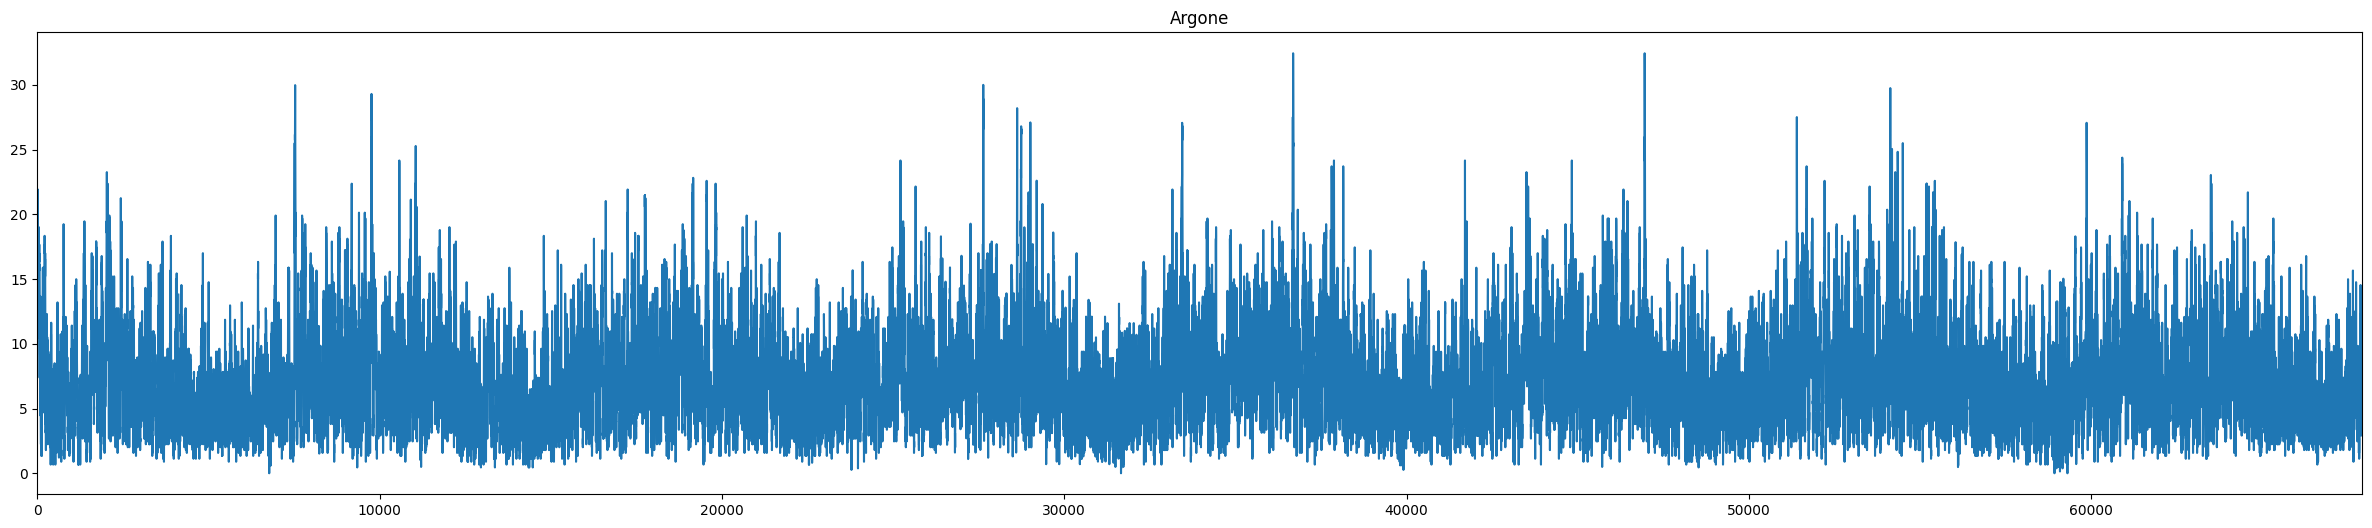

In [ ]:
plt.figure(figsize=(30, 6))
plt.plot(data_dict_loaded[names_TSF[0]]['time_series'])
plt.title(names_TSF[0])
plt.xlim(0, len(data_dict_loaded[names_TSF[0]]['time_series']))
plt.show()

In [ ]:
data = {}

for folder_name in names_TSF:
    print(f"\nFolder: {folder_name}")

    # Inicializar sección
    data[folder_name] = {}

    X = data_dict_loaded[f"{folder_name}"]['X']/data_dict_loaded[names_TSF[0]].get('Max')
    Y = data_dict_loaded[f"{folder_name}"]['Y']

    print(X.shape, Y.shape)

    X = X[..., np.newaxis]  # Expand dims for CNN

    print(X.shape, Y.shape)

    # Train/Validation/Test splits
    X_temp, X_test, y_temp, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
    X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

    if folder_name == "Etiopia-April" or folder_name == "Etiopia-May":
        batch_size = 64
    else:
        batch_size = 256

    train_loader = make_loader(X_train, y_train, batch_size)
    valid_loader = make_loader(X_valid, y_valid, batch_size)
    test_loader  = make_loader(X_test,  y_test, batch_size)

    data[folder_name] = {"loaders": {"train": train_loader, "valid": valid_loader, "test":  test_loader}}


Folder: Argone
(67892, 20) (67892, 7)
(67892, 20, 1) (67892, 7)


# **Models**

## **Loss function**

In [ ]:
class KernelMSELoss_PT(nn.Module):
    def __init__(self, sigma=None):
        super(KernelMSELoss_PT, self).__init__()
        if sigma is None:
            sigma = math.sqrt(2) / 2
        self.sigma2 = 2 * sigma ** 2

    def forward(self, y_pred, y_true):
        diff_squared = (y_true - y_pred) ** 2
        loss = 1 - torch.exp(-diff_squared / self.sigma2)
        return torch.mean(loss)

## RFF custom layer

In [ ]:
import torch
import torch.nn as nn
import numpy as np

class DenseRFF_PT(nn.Module):
    def __init__(self, Nf, scale=None, gamma=None, normalization=True,
                 function="cos", trainable_scale=True, trainable_W=True,
                 seed=None, kernel='gaussian'):
        """
        Implementación de Random Fourier Features (RFF).
        """
        super(DenseRFF_PT, self).__init__()
        self.Nf = Nf
        self.gamma = gamma
        self.scale = scale
        self.normalization = normalization
        self.function = function
        self.trainable_scale = trainable_scale
        self.trainable_W = trainable_W
        self.seed = seed
        self.kernel_type = kernel

        self.W = None
        self.b = None
        self.kernel_scale = None

    def _get_random_features_initializer(self, shape, sigma=1.0, seed=None):
        if seed is not None:
            np.random.seed(seed)
        if self.kernel_type == 'gaussian':
            return np.random.randn(*shape) / sigma
        elif self.kernel_type == 'laplacian':
            return np.random.laplace(loc=0.0, scale=1.0, size=shape) / sigma
        else:
            raise ValueError(f'Unsupported initializer {self.kernel_type}')

    def forward(self, inputs):
        device = inputs.device

        # Espera [B,T,D] o [B,D]; no hace permutaciones automáticas
        if inputs.dim() == 2:
            inputs = inputs.unsqueeze(1)   # [B,D] -> [B,1,D]
        elif inputs.dim() != 3:
            raise ValueError(f"Se esperaba [B,T,D] o [B,D], recibido: {inputs.shape}")

        B, T, D = inputs.shape

        if self.W is None:
            if self.gamma is not None:
                sigma = np.sqrt(1.0 / (2 * self.gamma))
            else:
                sigma = 1.0
            if self.scale is None:
                self.scale = sigma

            W_init = self._get_random_features_initializer((D, self.Nf), sigma=self.scale, seed=self.seed)
            self.W = nn.Parameter(torch.tensor(W_init, dtype=torch.float32, device=device),
                                  requires_grad=self.trainable_W)

            b_init = np.random.uniform(0.0, 2 * np.pi, size=(self.Nf,))
            self.b = nn.Parameter(torch.tensor(b_init, dtype=torch.float32, device=device),
                                  requires_grad=self.trainable_W)

            self.kernel_scale = nn.Parameter(torch.tensor([1.0], dtype=torch.float32, device=device),
                                             requires_grad=self.trainable_scale)

        proj = torch.matmul(inputs, self.W * self.kernel_scale) + self.b  # [B,T,Nf]

        if self.function == "cos":
            outputs = torch.cos(proj)
            norm = np.sqrt(self.Nf)
        elif self.function == "sin":
            outputs = torch.sin(proj)
            norm = np.sqrt(self.Nf)
        elif self.function == "cos_sin":
            outputs = torch.cat([torch.cos(proj), torch.sin(proj)], dim=-1)
            norm = np.sqrt(2*self.Nf)   # ajuste correcto
        else:
            raise ValueError(f"Función desconocida {self.function}")

        outputs = outputs * np.sqrt(2.0)
        if self.normalization:
            outputs = outputs / norm

        return outputs.permute(0, 2, 1)  # [B,Nf( o 2Nf si cos_sin), T]




In [ ]:
rff_layer = DenseRFF_PT(Nf=100, gamma=0.5, function="cos", normalization=True, seed=123)
x = torch.randn(100, 30, 1)   # (batch, window, channels)
y = rff_layer(x)

print("Input:", x.shape)
print("Output:", y.shape)

Input: torch.Size([100, 30, 1])
Output: torch.Size([100, 100, 30])


## RNN + RFF

In [ ]:
class DenseRFF_ForecastNet(nn.Module):
    def __init__(self,
                 window: int = 30,
                 prediction_horizon: int = 7,
                 rff_output_dim: int = 64,
                 rnn_type: str = None,
                 rnn_hidden_size: int = 32,
                 rnn_num_layers: int = 1,
                 rnn_bidirectional: bool = False):
        super().__init__()

        self.prediction_horizon = prediction_horizon
        self.rff_output_dim = rff_output_dim
        self.use_rnn = rnn_type is not None

        # 1) RNN opcional
        if self.use_rnn:
            rnn_cls = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[rnn_type]
            self.rnn = rnn_cls(
                input_size=1,
                hidden_size=rnn_hidden_size,
                num_layers=rnn_num_layers,
                bidirectional=rnn_bidirectional,
                batch_first=True
            )
            self.rnn_out_dim = rnn_hidden_size * (2 if rnn_bidirectional else 1)
        else:
            self.rnn_out_dim = 1

        # 2) Capa RFF densa
        self.rff = DenseRFF_PT(
            Nf=rff_output_dim,
            gamma=None,
            scale=None,
            function="cos",
            normalization=True,
            trainable_scale=True,
            trainable_W=True,
            seed=42,
            kernel="gaussian"
        )

        # 3) Capa fully-connected
        # ⚠️ No inicializamos fc1 aquí, la creamos en el primer forward
        self.fc1 = None
        self.fc2 = nn.Linear(128, prediction_horizon)  # salida fija

        self.relu = nn.ReLU()

    def forward(self, x):
        # Entrada [B, T, 1]
        if self.use_rnn:
            x, _ = self.rnn(x)   # [B, T, H]
        # Si no hay RNN, ya es [B,T,1]

        # Aplicar RFF
        x = self.rff(x)  # [B, Nf, T]

        # Flatten
        x = x.reshape(x.size(0), -1)  # [B, Nf*T]

        # Inicializar fc1 dinámicamente si no existe
        if self.fc1 is None:
            self.fc1 = nn.Linear(x.size(1), 128).to(x.device)

        x = self.fc1(x)
        x = self.relu(x)
        return self.fc2(x)



## Train


In [ ]:
def train_model(model, data, folder_name, num_epochs=50, lr=1e-3, device="cuda", trial=None):
    loaders = data[folder_name]["loaders"]
    train_loader = loaders["train"]
    valid_loader = loaders["valid"]
    test_loader  = loaders["test"]

    # Detectar hiperparámetros del dataset
    xb0, yb0 = next(iter(train_loader))
    window  = xb0.shape[1]
    horizon = yb0.shape[1]

    # Ajuste dinámico de la capa de salida (por si cambia el dataset)
    if hasattr(model, "fc2") and model.fc2.out_features != horizon:
        model.fc2 = nn.Linear(model.fc2.in_features, horizon).to(device)

    model = model.to(device)
    #criterion = KernelMSELoss_PT()
    criterion = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val = float("inf")
    history = {"train_loss": [], "valid_loss": []}

    for epoch in range(1, num_epochs + 1):
        # -------- Train
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.size(0)
        train_loss /= len(train_loader.dataset)

        # -------- Valid
        model.eval()
        valid_loss = 0.0
        with torch.no_grad():
            for xb, yb in valid_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                valid_loss += loss.item() * xb.size(0)
        valid_loss /= len(valid_loader.dataset)

        history["train_loss"].append(train_loss)
        history["valid_loss"].append(valid_loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | Train {train_loss:.4f} | Valid {valid_loss:.4f}")

        # Guardar mejor
        if valid_loss < best_val:
            best_val = valid_loss
            torch.save(model.state_dict(), f"best_model_{folder_name}.pth")

        # NEW: Reportar a Optuna y activar pruning
        if trial is not None:
            # Reportamos -valid_loss para que "más alto es mejor" (consistente con maximize)
            trial.report(-valid_loss, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

    # -------- Test con mejor modelo
    model.load_state_dict(torch.load(f"best_model_{folder_name}.pth", map_location=device))
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            y_true.append(yb.cpu())
            y_pred.append(preds.cpu())

    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()

    # Métricas globales
    r2   = float(r2_score(y_true, y_pred))
    mae  = float(mean_absolute_error(y_true, y_pred))
    mse  = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))
    print(f"Test GLOBAL | R2={r2:.4f} | MAE={mae:.4f} | RMSE={rmse:.4f}")

    # Métricas puntuales
    H = y_true.shape[1]
    metrics_pointwise = {"horizon": [], "RMSE": [], "MAE": [], "R2": []}
    for h in range(H):
        yt = y_true[:, h]
        yp = y_pred[:, h]
        mse_h = mean_squared_error(yt, yp)
        rmse_h = np.sqrt(mse_h)
        mae_h  = mean_absolute_error(yt, yp)
        r2_h   = r2_score(yt, yp)
        metrics_pointwise["horizon"].append(h+1)
        metrics_pointwise["RMSE"].append(float(rmse_h))
        metrics_pointwise["MAE"].append(float(mae_h))
        metrics_pointwise["R2"].append(float(r2_h))
    df_pointwise = pd.DataFrame(metrics_pointwise)

    #print("\t\n", df_pointwise)

    # Métricas acumuladas
    metrics_cumulative = {"horizon": [], "RMSE": [], "MAE": [], "R2": []}
    for h in range(1, H+1):
        yt = y_true[:, :h].reshape(-1)
        yp = y_pred[:, :h].reshape(-1)
        mse_h = mean_squared_error(yt, yp)
        rmse_h = np.sqrt(mse_h)
        mae_h  = mean_absolute_error(yt, yp)
        r2_h   = r2_score(yt, yp)
        metrics_cumulative["horizon"].append(h)
        metrics_cumulative["RMSE"].append(float(rmse_h))
        metrics_cumulative["MAE"].append(float(mae_h))
        metrics_cumulative["R2"].append(float(r2_h))
    df_cumulative = pd.DataFrame(metrics_cumulative)

    #print("\t\n", df_cumulative)

    return history, df_pointwise, df_cumulative





In [ ]:
def plot_reconstruction_per_horizon(y_true, y_pred, num_samples=500, folder_name="dataset"):
    N, H = y_true.shape
    num_samples = min(num_samples, N)

    for h in range(H):
        plt.figure(figsize=(14, 4))
        plt.plot(range(num_samples), y_true[:num_samples, h],
                 label=f"Real (h={h+1})", color="blue", linewidth=1.5)
        plt.plot(range(num_samples), y_pred[:num_samples, h],
                 label=f"Predicho (h={h+1})", color="red", linestyle="--")
        plt.title(f"Reconstrucción Test - {folder_name} (Horizonte {h+1})")
        plt.xlabel("Índice de muestra")
        plt.ylabel("Valor")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()



# **Bayes optimization**

In [ ]:
from functools import partial
import os, shutil, optuna
from optuna.samplers import TPESampler

def objetive_cmae(
    trial,
    net_type: str,                     # None | "RNN" | "GRU" | "LSTM"
    *,
    dataset_key: str,                  # clave EXACTA en data[...] (p.ej. "Beijing", "Lorenz systems 0.5")
    window: int,
    horizon: int,
    data: dict,
    lr: float = 1e-3,
    num_epochs: int = 60,
    device: str = "cuda",
    rff_dim_choices=(16, 32, 64, 96, 128, 192, 256),
    rnn_hidden_size: int = 64,
    rnn_num_layers: int = 1,
    rnn_bidirectional: bool = False,
    run_dir_base: str = "runs/rffdim_search",
):
    # Validación para evitar KeyError
    if dataset_key not in data or "loaders" not in data[dataset_key]:
        raise KeyError(f"dataset_key='{dataset_key}' no válido. Claves: {list(data.keys())}")

    # ÚNICO hiperparámetro a optimizar
    rff_output_dim = trial.suggest_categorical("rff_output_dim", list(rff_dim_choices))

    # Modelo
    model = DenseRFF_ForecastNet(
        window=window,
        prediction_horizon=horizon,
        rff_output_dim=rff_output_dim,
        rnn_type=net_type,
        rnn_hidden_size=rnn_hidden_size,
        rnn_num_layers=rnn_num_layers,
        rnn_bidirectional=rnn_bidirectional,
    )

    # ENTRENAR (nota: folder_name debe ser la clave del dataset)
    history, df_pointwise, df_cumulative = train_model(
        model=model,
        data=data,
        folder_name=dataset_key,
        num_epochs=num_epochs,
        lr=lr,
        device=device,
        trial=trial,
    )

    # MAE acumulativo en TEST: última fila (agrega todos los horizontes)
    cmae_test = float(df_cumulative["MAE"].iloc[-1])

    # Guarda para análisis posterior
    trial.set_user_attr("cmae_test", cmae_test)
    trial.set_user_attr("rff_output_dim", int(rff_output_dim))
    trial.set_user_attr("cmae_curve", df_cumulative["MAE"].tolist())

    # (opcional) Copiar el mejor modelo a carpeta del trial
    src = f"best_model_{dataset_key}.pth"
    dst_dir = os.path.join(run_dir_base, dataset_key, f"trial{trial.number}_rff{rff_output_dim}")
    os.makedirs(dst_dir, exist_ok=True)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(dst_dir, os.path.basename(src)))

    # OBJETIVO: MINIMIZAR el MAE acumulativo
    return cmae_test



In [ ]:
dataset_key = names_TSF[0]

# Inferir window/horizon una sola vez desde los loaders del dataset elegido
xb0, yb0 = next(iter(data[dataset_key]["loaders"]["train"]))
window  = int(xb0.shape[1])
horizon = int(yb0.shape[1])

# Redes a evaluar: Dense (None), RNN, GRU, LSTM
nets = [
    ("Dense", None),
    ("RNN",   "RNN"),
    ("GRU",   "GRU"),
    ("LSTM",  "LSTM"),
]

# Para guardar estudios y resultados
studies   = {}
rows_all  = []

from functools import partial
import optuna
from optuna.samplers import TPESampler
from optuna.trial import TrialState

for label, net_type in nets:
    print(f"\n===================== Optimizando {label} en dataset={dataset_key} =====================")

    # Sampler/Pruner por estudio (igual que tu patrón original)
    sampler = TPESampler(seed=42)
    pruner  = optuna.pruners.NopPruner()

    study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)

    # Mismo esquema que tu ejemplo, solo cambiando net_type y run_dir_base
    objective_net = partial(
        objetive_cmae,
        net_type=net_type,
        dataset_key=dataset_key,
        window=window,
        horizon=horizon,
        data=data,
        lr=1e-3,
        num_epochs=100,
        device=device,
        rff_dim_choices=tuple(range(4, 101, 1)),
        rnn_hidden_size=32,
        rnn_num_layers=1,
        rnn_bidirectional=False,
        run_dir_base=f"runs/{label.lower()}_rffdim_search",
    )

    study.optimize(objective_net, n_trials=25, gc_after_trial=True)

    print("Best CMAE:", study.best_value)
    print("Best params:", study.best_trial.params)

    studies[label] = study

    # Guardar todos los trials para graficar error vs parámetro
    for t in study.trials:
        if t.state != TrialState.COMPLETE:
            continue
        rows_all.append({
            "net_type": label,
            "trial": t.number,
            "rff_output_dim": int(t.params["rff_output_dim"]),
            "cmae_test": float(t.user_attrs.get("cmae_test", t.value)),  # guardado en objetive_cmae
        })


[I 2025-10-03 13:53:51,491] A new study created in memory with name: no-name-0793f274-b57c-4326-a27f-ac82c5c0ea13



===================== Optimizando Dense en dataset=Argone =====================
Epoch 010 | Train 0.0913 | Valid 0.0917
Epoch 020 | Train 0.0911 | Valid 0.0916
Epoch 030 | Train 0.0909 | Valid 0.0914
Epoch 040 | Train 0.0907 | Valid 0.0911
Epoch 050 | Train 0.0905 | Valid 0.0909
Epoch 060 | Train 0.0903 | Valid 0.0907
Epoch 070 | Train 0.0901 | Valid 0.0905
Epoch 080 | Train 0.0899 | Valid 0.0903
Epoch 090 | Train 0.0897 | Valid 0.0901


[I 2025-10-03 13:55:13,867] Trial 0 finished with value: 0.08940138667821884 and parameters: {'rff_output_dim': 73}. Best is trial 0 with value: 0.08940138667821884.


Epoch 100 | Train 0.0895 | Valid 0.0899
Test GLOBAL | R2=-0.0088 | MAE=0.0894 | RMSE=0.1177
Epoch 010 | Train 0.0911 | Valid 0.0916
Epoch 020 | Train 0.0907 | Valid 0.0911
Epoch 030 | Train 0.0902 | Valid 0.0907
Epoch 040 | Train 0.0898 | Valid 0.0902
Epoch 050 | Train 0.0893 | Valid 0.0897
Epoch 060 | Train 0.0889 | Valid 0.0893
Epoch 070 | Train 0.0885 | Valid 0.0888
Epoch 080 | Train 0.0881 | Valid 0.0884
Epoch 090 | Train 0.0877 | Valid 0.0880


[I 2025-10-03 13:56:22,753] Trial 1 finished with value: 0.08717089146375656 and parameters: {'rff_output_dim': 61}. Best is trial 1 with value: 0.08717089146375656.


...

Epoch 100 | Train 0.0637 | Valid 0.0637
Test GLOBAL | R2=0.4716 | MAE=0.0637 | RMSE=0.0851
Epoch 010 | Train 0.0789 | Valid 0.0770
Epoch 020 | Train 0.0714 | Valid 0.0704
Epoch 030 | Train 0.0682 | Valid 0.0675
Epoch 040 | Train 0.0668 | Valid 0.0665
Epoch 050 | Train 0.0659 | Valid 0.0659
Epoch 060 | Train 0.0652 | Valid 0.0649
Epoch 070 | Train 0.0646 | Valid 0.0645
Epoch 080 | Train 0.0642 | Valid 0.0642
Epoch 090 | Train 0.0638 | Valid 0.0638


[I 2025-10-03 16:05:50,392] Trial 23 finished with value: 0.0637500062584877 and parameters: {'rff_output_dim': 79}. Best is trial 3 with value: 0.06358637660741806.


Epoch 100 | Train 0.0635 | Valid 0.0637
Test GLOBAL | R2=0.4660 | MAE=0.0638 | RMSE=0.0855
Epoch 010 | Train 0.0772 | Valid 0.0771
Epoch 020 | Train 0.0700 | Valid 0.0691
Epoch 030 | Train 0.0676 | Valid 0.0668
Epoch 040 | Train 0.0664 | Valid 0.0658
Epoch 050 | Train 0.0656 | Valid 0.0654
Epoch 060 | Train 0.0650 | Valid 0.0648
Epoch 070 | Train 0.0645 | Valid 0.0641
Epoch 080 | Train 0.0641 | Valid 0.0639
Epoch 090 | Train 0.0639 | Valid 0.0639
Epoch 100 | Train 0.0638 | Valid 0.0638
Test GLOBAL | R2=0.4727 | MAE=0.0638 | RMSE=0.0850


[I 2025-10-03 16:07:14,648] Trial 24 finished with value: 0.06375771015882492 and parameters: {'rff_output_dim': 33}. Best is trial 3 with value: 0.06358637660741806.


Best CMAE: 0.06358637660741806
Best params: {'rff_output_dim': 18}


In [ ]:
# Resúmenes útiles
df_trials = pd.DataFrame(rows_all).sort_values(["net_type","rff_output_dim","cmae_test"]).reset_index(drop=True)
df_best = pd.DataFrame(
    [{"net_type": lbl,
      "best_rff_output_dim": int(st.best_trial.params["rff_output_dim"]),
      "best_cmae": float(st.best_value)} for lbl, st in studies.items()]
).sort_values("best_cmae").reset_index(drop=True)

display(df_best)


,net_type,best_rff_output_dim,best_cmae
0,GRU,30,0.063275
1,RNN,5,0.063415
2,LSTM,18,0.063586
3,Dense,4,0.081528


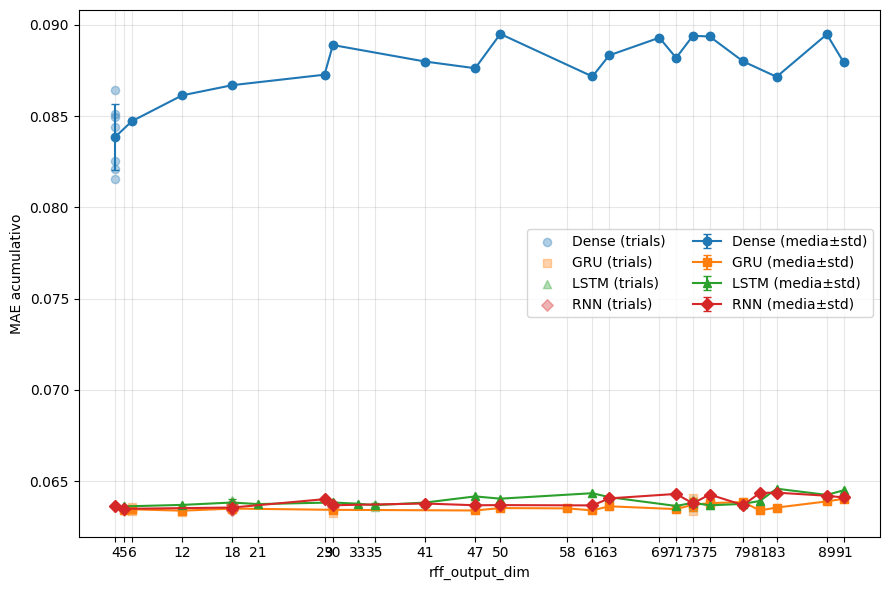

In [ ]:
dfp = df_trials.copy()
dfp["rff_output_dim"] = dfp["rff_output_dim"].astype(int)
dfp = dfp.sort_values(["net_type","rff_output_dim","cmae_test"]).reset_index(drop=True)

# Agregado por red y parámetro
agg = (
    dfp.groupby(["net_type","rff_output_dim"])["cmae_test"]
       .agg(["mean","std","count"])
       .reset_index()
)

plt.figure(figsize=(9,6))

markers = ["o", "s", "^", "D", "P", "X"]
marker_map = {}

for i, net in enumerate(sorted(dfp["net_type"].unique())):
    # scatter: todos los trials de esa red
    sub = dfp[dfp["net_type"] == net]
    marker_map[net] = markers[i % len(markers)]
    plt.scatter(
        sub["rff_output_dim"], sub["cmae_test"],
        alpha=0.35, s=35, label=f"{net} (trials)", marker=marker_map[net]
    )

    # línea + barras de error: media ± std
    suba = agg[agg["net_type"] == net].sort_values("rff_output_dim")
    plt.errorbar(
        suba["rff_output_dim"], suba["mean"], yerr=suba["std"],
        fmt=f"-{marker_map[net]}", capsize=3, linewidth=1.5, label=f"{net} (media±std)"
    )

# Mejor punto global (anotación)
best_idx = dfp["cmae_test"].idxmin()
best_x   = int(dfp.loc[best_idx, "rff_output_dim"])
best_y   = float(dfp.loc[best_idx, "cmae_test"])
best_net = dfp.loc[best_idx, "net_type"]

#plt.annotate(f"Mejor: {best_net}, dim={best_x}, CMAE={best_y:.4f}", xy=(best_x, best_y), xytext=(10, 12), textcoords="offset points", arrowprops=dict(arrowstyle="->", lw=1))

plt.xlabel("rff_output_dim")
plt.ylabel("MAE acumulativo")
plt.grid(True, alpha=0.3)
plt.xticks(sorted(dfp["rff_output_dim"].unique()))
plt.legend(ncols=2, frameon=True)
plt.tight_layout()
plt.show()


# **Forecasting**

In [ ]:
results = {}

window = data_dict_loaded[folder_name]['X'].shape[1]          # longitud de la ventana
horizon = data_dict_loaded[folder_name]['Y'].shape[1]         # horizonte de predicción

for _, row in df_best.iterrows():
    print(f"\n🏋️‍♀️💻 ====================================== Training: RFF-{row['net_type']} \n\t")

    net_type = row['net_type']
    if net_type == "Dense":
        net_type = None

    model = DenseRFF_ForecastNet(
        window=window,
        prediction_horizon=horizon,
        rff_output_dim=row['best_rff_output_dim'],
        rnn_type=net_type,
        rnn_hidden_size=32,
        rnn_num_layers=1
    )

    history, df_pointwise, df_cumulative = train_model(
        model,
        data,
        folder_name=names_TSF[0],
        num_epochs=500,
        lr=1e-3,
        device="cuda" if torch.cuda.is_available() else "cpu"
    )

    print(df_cumulative)

    # Añadir columna con el tipo de red
    df_cumulative["net_type"] = row['net_type']

    # Guardar en lista de resultados
    results[f"RFF-{row['net_type']}"] = df_cumulative.copy()



🏋️‍♀️💻 ====================================== Training: RFF-GRU 
	
Epoch 010 | Train 0.0720 | Valid 0.0707
Epoch 020 | Train 0.0680 | Valid 0.0675
Epoch 030 | Train 0.0666 | Valid 0.0664
Epoch 040 | Train 0.0657 | Valid 0.0653
Epoch 050 | Train 0.0649 | Valid 0.0646
Epoch 060 | Train 0.0643 | Valid 0.0642
Epoch 070 | Train 0.0640 | Valid 0.0639
Epoch 080 | Train 0.0637 | Valid 0.0636
Epoch 090 | Train 0.0636 | Valid 0.0635
Epoch 100 | Train 0.0635 | Valid 0.0634
Epoch 110 | Train 0.0634 | Valid 0.0634
Epoch 120 | Train 0.0633 | Valid 0.0634
Epoch 130 | Train 0.0633 | Valid 0.0633
Epoch 140 | Train 0.0633 | Valid 0.0633
Epoch 150 | Train 0.0633 | Valid 0.0634
Epoch 160 | Train 0.0632 | Valid 0.0633
Epoch 170 | Train 0.0632 | Valid 0.0634
Epoch 180 | Train 0.0632 | Valid 0.0633
Epoch 190 | Train 0.0631 | Valid 0.0632
Epoch 200 | Train 0.0631 | Valid 0.0631
Epoch 210 | Train 0.0631 | Valid 0.0632
Epoch 220 | Train 0.0631 | Valid 0.0633
Epoch 230 | Train 0.0631 | Valid 0.0633
Epoch 240 | 

In [ ]:
results

{'RFF-GRU':    horizon      RMSE       MAE        R2 net_type
 0        1  0.058665  0.043692  0.752153      GRU
 1        2  0.064789  0.048304  0.697331      GRU
 2        3  0.069837  0.052114  0.646770      GRU
 3        4  0.074230  0.055457  0.599929      GRU
 4        5  0.078202  0.058436  0.555308      GRU
 5        6  0.081655  0.060988  0.515048      GRU
 6        7  0.084410  0.063144  0.481089      GRU,
 'RFF-RNN':    horizon      RMSE       MAE        R2 net_type
 0        1  0.058440  0.043613  0.754054      RNN
 1        2  0.064643  0.048261  0.698693      RNN
 2        3  0.069750  0.052095  0.647645      RNN
 3        4  0.074246  0.055457  0.599766      RNN
 4        5  0.078095  0.058456  0.556522      RNN
 5        6  0.081488  0.061018  0.517038      RNN
 6        7  0.084332  0.063177  0.482046      RNN,
 'RFF-LSTM':    horizon      RMSE       MAE        R2 net_type
 0        1  0.058433  0.043537  0.754112     LSTM
 1        2  0.064660  0.048143  0.698540     

In [ ]:
df_summary = pd.concat(results, ignore_index=True)
print(df_summary)

    horizon      RMSE       MAE        R2 net_type
0         1  0.058665  0.043692  0.752153      GRU
1         2  0.064789  0.048304  0.697331      GRU
2         3  0.069837  0.052114  0.646770      GRU
3         4  0.074230  0.055457  0.599929      GRU
4         5  0.078202  0.058436  0.555308      GRU
5         6  0.081655  0.060988  0.515048      GRU
6         7  0.084410  0.063144  0.481089      GRU
7         1  0.058440  0.043613  0.754054      RNN
8         2  0.064643  0.048261  0.698693      RNN
9         3  0.069750  0.052095  0.647645      RNN
10        4  0.074246  0.055457  0.599766      RNN
11        5  0.078095  0.058456  0.556522      RNN
12        6  0.081488  0.061018  0.517038      RNN
13        7  0.084332  0.063177  0.482046      RNN
14        1  0.058433  0.043537  0.754112     LSTM
15        2  0.064660  0.048143  0.698540     LSTM
16        3  0.069684  0.051960  0.648316     LSTM
17        4  0.074046  0.055296  0.601915     LSTM
18        5  0.078047  0.058288

In [ ]:
import torch
import torch.nn as nn

class RecurrentForecastNet(nn.Module):
    """
    Mismo esqueleto que DenseRFF_ForecastNet pero SIN capa RFF:
      (opcional) RNN -> [B,T,F]  --transponer--> [B,F,T] --flatten--> FC(·,128) -> ReLU -> FC(128,H)

    Entrada:  x de forma [B, T, 1]
    Salida:   y_hat de forma [B, prediction_horizon]
    """
    def __init__(self,
                 window: int = 30,
                 prediction_horizon: int = 7,
                 # (Se conserva la firma para comparar uno-a-uno)
                 rff_output_dim: int = 64,          # <- ignorado en esta clase; se deja por compatibilidad
                 rnn_type: str = None,              # None | 'RNN' | 'GRU' | 'LSTM'
                 rnn_hidden_size: int = 32,
                 rnn_num_layers: int = 1,
                 rnn_bidirectional: bool = False):
        super().__init__()

        self.prediction_horizon = prediction_horizon
        self.use_rnn = rnn_type is not None

        if self.use_rnn:
            if rnn_type not in {"RNN", "GRU", "LSTM"}:
                raise ValueError("rnn_type debe ser 'RNN', 'GRU', 'LSTM' o None.")
            rnn_cls = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[rnn_type]
            self.rnn = rnn_cls(
                input_size=1,
                hidden_size=rnn_hidden_size,
                num_layers=rnn_num_layers,
                bidirectional=rnn_bidirectional,
                batch_first=True
            )
            feat = rnn_hidden_size * (2 if rnn_bidirectional else 1)  # F
        else:
            self.rnn = None
            feat = 1  # si no hay RNN, mantenemos el canal original

        # Igual que en tu clase original: fc1 se define en el primer forward
        self.fc1 = None
        self.fc2 = nn.Linear(128, prediction_horizon)
        self.relu = nn.ReLU()

        # guardamos F para documentar, no es obligatorio
        self._feat = feat

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, T, 1]
        """
        # 1) Paso recurrente opcional: out [B, T, F]
        if self.use_rnn:
            x, _ = self.rnn(x)  # [B, T, F]
        # si no hay RNN, x ya es [B, T, 1] → F=1

        # 2) Transponer para emular la forma [B, F, T] que antes salía de RFF
        x = x.transpose(1, 2)  # [B, F, T]

        # 3) Aplanar tiempo y features como en tu DenseRFF (Nf*T → ahora F*T)
        x = x.reshape(x.size(0), -1)  # [B, F*T]

        # 4) Inicializar fc1 de forma diferida (como en tu clase original)
        if self.fc1 is None:
            self.fc1 = nn.Linear(x.size(1), 128).to(x.device)

        x = self.fc1(x)
        x = self.relu(x)
        return self.fc2(x)



In [ ]:
# Filtrar solo redes recurrentes válidas
valid_nets = {"RNN", "GRU", "LSTM"}
df_run = df_best[df_best["net_type"].isin(valid_nets)].copy()

for _, row in df_run.iterrows():
    print(f"\n🏋️‍♀️💻 ====================================== Training: {row['net_type']} \n\t")

    net_type = row['net_type']  # 'RNN' | 'GRU' | 'LSTM'

    # ---- Modelo SOLO recurrente (sin RFF) ----
    model = RecurrentForecastNet(
          window=window,
          prediction_horizon=horizon,
          rnn_type=net_type,        # None | 'RNN' | 'GRU' | 'LSTM'
          rnn_hidden_size=32,
          rnn_num_layers=1,
          rnn_bidirectional=False
      )

    # ---- Entrenar ----
    history, df_pointwise, df_cumulative = train_model(
        model=model,
        data=data,
        folder_name=folder_name,   # clave del dataset en 'data'
        num_epochs=500,
        lr=1e-3,
        device=device
    )

    print(df_cumulative)

    df_cumulative["net_type"] = net_type

    results[f"{row['net_type']}"] = df_cumulative.copy()




🏋️‍♀️💻 ====================================== Training: GRU 
	
Epoch 010 | Train 0.0738 | Valid 0.0728
Epoch 020 | Train 0.0691 | Valid 0.0687
Epoch 030 | Train 0.0674 | Valid 0.0671
Epoch 040 | Train 0.0662 | Valid 0.0659
Epoch 050 | Train 0.0653 | Valid 0.0651
Epoch 060 | Train 0.0646 | Valid 0.0644
Epoch 070 | Train 0.0641 | Valid 0.0639
Epoch 080 | Train 0.0637 | Valid 0.0637
Epoch 090 | Train 0.0635 | Valid 0.0635
Epoch 100 | Train 0.0633 | Valid 0.0634
Epoch 110 | Train 0.0632 | Valid 0.0633
Epoch 120 | Train 0.0631 | Valid 0.0632
Epoch 130 | Train 0.0631 | Valid 0.0632
Epoch 140 | Train 0.0630 | Valid 0.0631
Epoch 150 | Train 0.0630 | Valid 0.0631
Epoch 160 | Train 0.0630 | Valid 0.0631
Epoch 170 | Train 0.0629 | Valid 0.0630
Epoch 180 | Train 0.0629 | Valid 0.0630
Epoch 190 | Train 0.0629 | Valid 0.0630
Epoch 200 | Train 0.0628 | Valid 0.0631
Epoch 210 | Train 0.0628 | Valid 0.0630
Epoch 220 | Train 0.0628 | Valid 0.0630
Epoch 230 | Train 0.0628 | Valid 0.0630
Epoch 240 | Trai

In [ ]:
results

{'RFF-GRU':    horizon      RMSE       MAE        R2 net_type
 0        1  0.058665  0.043692  0.752153      GRU
 1        2  0.064789  0.048304  0.697331      GRU
 2        3  0.069837  0.052114  0.646770      GRU
 3        4  0.074230  0.055457  0.599929      GRU
 4        5  0.078202  0.058436  0.555308      GRU
 5        6  0.081655  0.060988  0.515048      GRU
 6        7  0.084410  0.063144  0.481089      GRU,
 'RFF-RNN':    horizon      RMSE       MAE        R2 net_type
 0        1  0.058440  0.043613  0.754054      RNN
 1        2  0.064643  0.048261  0.698693      RNN
 2        3  0.069750  0.052095  0.647645      RNN
 3        4  0.074246  0.055457  0.599766      RNN
 4        5  0.078095  0.058456  0.556522      RNN
 5        6  0.081488  0.061018  0.517038      RNN
 6        7  0.084332  0.063177  0.482046      RNN,
 'RFF-LSTM':    horizon      RMSE       MAE        R2 net_type
 0        1  0.058433  0.043537  0.754112     LSTM
 1        2  0.064660  0.048143  0.698540     

In [ ]:
import pandas as pd
from tabulate import tabulate

# Unificar todos los DataFrames del diccionario en uno solo
df_all = pd.concat(results, axis=0)
df_all.reset_index(inplace=True)
df_all.rename(columns={"level_0": "Model", "level_1": "Index"}, inplace=True)
df_all.drop(columns=["Index"], inplace=True)

# Mostrar tabla completa (primeras filas) con tabulate
print("\n📊 Resultados organizados:")
print(tabulate(df_all.head(20), headers="keys", tablefmt="grid", showindex=False))

# También puedes pivotear para comparar métricas por horizonte
df_pivot_rmse = df_all.pivot(index="horizon", columns="Model", values="RMSE")
df_pivot_mae  = df_all.pivot(index="horizon", columns="Model", values="MAE")
df_pivot_r2   = df_all.pivot(index="horizon", columns="Model", values="R2")

print("\n🔎 RMSE comparativo por horizonte:")
print(tabulate(df_pivot_rmse, headers="keys", tablefmt="grid", floatfmt=".4f"))

print("\n🔎 MAE comparativo por horizonte:")
print(tabulate(df_pivot_mae, headers="keys", tablefmt="grid", floatfmt=".4f"))

print("\n🔎 R2 comparativo por horizonte:")
print(tabulate(df_pivot_r2, headers="keys", tablefmt="grid", floatfmt=".4f"))




📊 Resultados organizados:
+----------+-----------+-----------+-----------+----------+------------+
| Model    |   horizon |      RMSE |       MAE |       R2 | net_type   |
+==========+===========+===========+===========+==========+============+
| RFF-GRU  |         1 | 0.0586653 | 0.0436922 | 0.752153 | GRU        |
+----------+-----------+-----------+-----------+----------+------------+
| RFF-GRU  |         2 | 0.0647892 | 0.0483038 | 0.697331 | GRU        |
+----------+-----------+-----------+-----------+----------+------------+
| RFF-GRU  |         3 | 0.069837  | 0.0521142 | 0.64677  | GRU        |
+----------+-----------+-----------+-----------+----------+------------+
| RFF-GRU  |         4 | 0.0742305 | 0.0554571 | 0.599929 | GRU        |
+----------+-----------+-----------+-----------+----------+------------+
| RFF-GRU  |         5 | 0.0782023 | 0.058436  | 0.555308 | GRU        |
+----------+-----------+-----------+-----------+----------+------------+
| RFF-GRU  |         6 |